In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../../data/Ice_cream selling data.csv")

In [8]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [9]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [14]:
df.isnull().value_counts()

Temperature (°C)  Ice Cream Sales (units)
False             False                      49
Name: count, dtype: int64

In [12]:
df.duplicated().value_counts()

False    49
Name: count, dtype: int64

In [16]:
x = df[['Temperature (°C)']]
y = df[['Ice Cream Sales (units)']]

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
model = LinearRegression()

In [19]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-1.15]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[17.14]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [20]:
print("Coefe:" , model.coef_[0])

Coefe: [-1.14658686]


In [21]:
print("intercept :", model.intercept_)

intercept : [17.13921313]


In [25]:
prediction = model.predict(x_test)

In [27]:
mae = mean_absolute_error(y_test,prediction)
print("MAE :" , mae)

MAE : 11.752026695440602


In [30]:
r2 = r2_score(y_test,prediction)
print("R ^ 2 Score : ", r2)

R ^ 2 Score :  -0.5751270190188227


In [31]:
from sklearn.preprocessing import PolynomialFeatures

In [42]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

In [33]:
print(x_poly[:3])

[[ 1.         -4.66226268 21.73669327]
 [ 1.         -4.31655945 18.63268546]
 [ 1.         -4.21398476 17.7576676 ]]


In [34]:
poly_model = LinearRegression()
poly_model.fit(x_poly,y)

In [35]:
mae = mean_absolute_error(y_test, prediction)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 11.752026695440602


In [37]:
r2 = r2_score(y_test, prediction)
print("R^2 score:", r2)

R^2 score: -0.5751270190188227


/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


<Figure size 800x500 with 0 Axes>

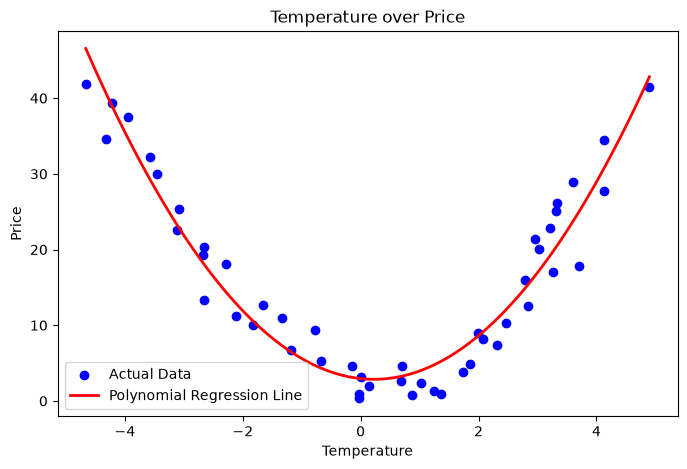

In [41]:

x_grid = np.linspace(x.min(), x.max(), 100)
x_grid = x_grid.reshape(-1, 1)
poly_model.fit(x_poly, y)
x_grid_poly = poly.transform(x_grid)
y_grid = poly_model.predict(x_grid_poly) 
plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='Polynomial Regression Line')
plt.xlabel("Temperature")
plt.ylabel("Price")
plt.title("Temperature over Price")
plt.legend()